In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [4]:
df = pd.read_csv("Cleaned_dataset.csv")
df

,Date,CustomerID,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,2023-01-04,C72649,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10
1,2024-08-23,C75739,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70
2,2024-02-27,C81728,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40
3,2023-10-15,C33540,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19
4,2025-05-08,C81840,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...
1195,2024-06-20,C21126,Desk,1,107.04,Credit Card,Cancelled,6,FREESHIP,Google,107.04
1196,2024-03-04,C20095,Monitor,2,662.53,Online,Cancelled,5,Not Used,Facebook,1325.06
1197,2023-07-13,C79674,Tablet,2,436.84,Online,Delivered,2,FREESHIP,Instagram,873.68
1198,2024-08-22,C64753,Chair,4,262.52,Debit Card,Cancelled,4,WINTER15,Instagram,1050.08


In [5]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [6]:
df.describe(include=object)

,Date,CustomerID,Product,PaymentMethod,OrderStatus,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200
unique,671,1189,7,5,5,4,5
top,2023-08-20,C38840,Printer,Online,Cancelled,FREESHIP,Instagram
freq,8,2,181,258,250,313,259


In [7]:
df.isnull().sum()

Date              0
CustomerID        0
Product           0
Quantity          0
UnitPrice         0
PaymentMethod     0
OrderStatus       0
ItemsInCart       0
CouponCode        0
ReferralSource    0
TotalPrice        0
dtype: int64

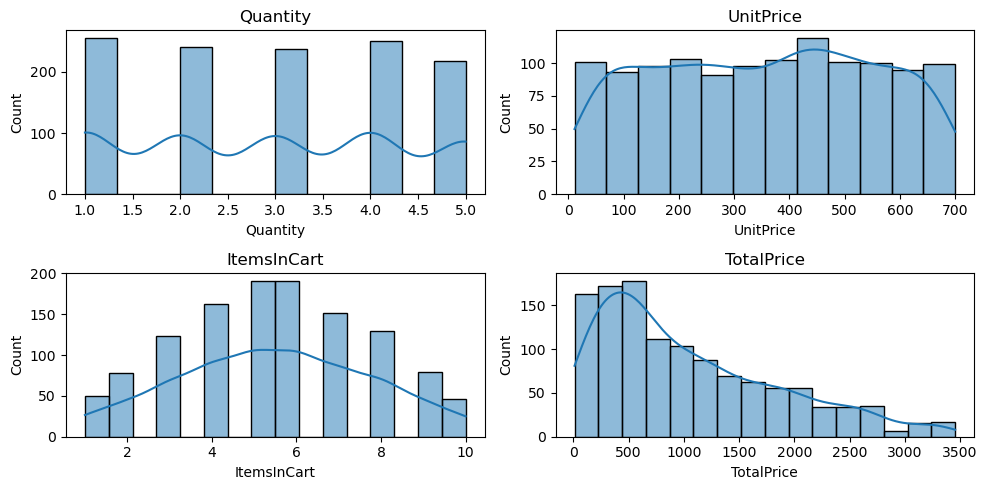

In [11]:
#analyzing numeric features 
number_columns = ['Quantity','UnitPrice' , 'ItemsInCart','TotalPrice']
fig,axes = plt.subplots(2,2,figsize = (10,5))
for ax , cols in zip(axes.flat,number_columns):
    sns.histplot(df[cols],kde=True , ax=ax)
    ax.set_title(cols)
plt.tight_layout()
plt.show()

In [24]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [25]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [26]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [27]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [28]:
#let do some relationship analysis
#Top revenue genrating product:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
product_revenue

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [31]:
df.groupby("PaymentMethod")["TotalPrice"].mean().sort_values(ascending=False)

PaymentMethod
Credit Card    1127.553974
Gift Card      1070.973565
Cash           1056.041829
Online         1017.220698
Debit Card     1001.556810
Name: TotalPrice, dtype: float64

In [32]:
#orderstatus vs revenue 
df.groupby("OrderStatus")["TotalPrice"].mean().sort_values(ascending=False)

OrderStatus
Cancelled    1105.584840
Pending      1081.553376
Delivered    1050.217835
Shipped      1047.487574
Returned      984.929960
Name: TotalPrice, dtype: float64

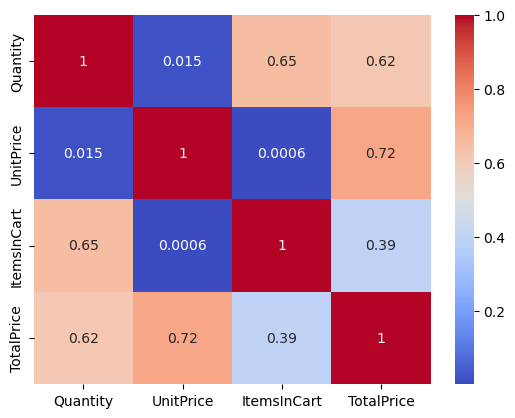

In [37]:
#correlation Heatmap
sns.heatmap(
    df[['Quantity' , 'UnitPrice' , 'ItemsInCart','TotalPrice']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [40]:
df['Date'].dtype

dtype('O')

In [41]:
df['Date'] = pd.to_datetime(df['Date'])

In [44]:
df['Date'].dtype

dtype('<M8[ns]')

In [51]:
#Monthly sales trend 

df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales

Month
April        109186.05
August        86343.21
December      82540.50
February     112344.78
January      124313.23
July          85784.64
June         170616.13
March        123840.93
May          135142.59
November      75493.43
October       89834.82
September     69321.65
Name: TotalPrice, dtype: float64

In [52]:
df.groupby('Month').size()   #orders per month 


Month
April        113
August        79
December      87
February     106
January      106
July          87
June         147
March        128
May          120
November      76
October       78
September     73
dtype: int64

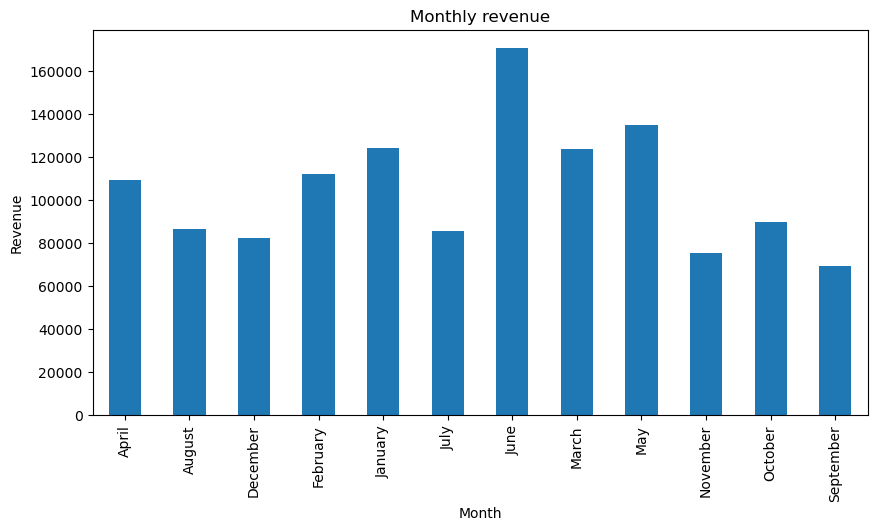

In [ ]:
monthly_sales.plot(kind ='bar' , figsize=(10,5))
plt.title("Monthly revenue")
plt.ylabel("Revenue")
plt.show()

In [61]:
# most spending customers 
top_customer_spender = df.groupby("CustomerID")['TotalPrice'].sum().sort_values(ascending=False)
top_customer_spender.head(10)

CustomerID
C38840    5723.23
C57276    3456.40
C67260    3390.80
C13877    3384.90
C18404    3370.20
C16775    3353.75
C65986    3352.40
C47778    3334.00
C59183    3322.55
C25276    3313.90
Name: TotalPrice, dtype: float64

In [62]:
avg_product = df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=False)
avg_product

Product
Laptop     1110.558150
Chair      1098.989382
Printer    1080.732652
Monitor    1077.616012
Tablet     1042.284637
Desk        985.058412
Phone       972.579423
Name: TotalPrice, dtype: float64

In [63]:
pd.crosstab(df['Product'] , df['OrderStatus'])

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Product,,,,,
Chair,45,33,41,28,31
Desk,35,32,38,32,33
Laptop,35,40,30,39,29
Monitor,35,31,29,36,32
Phone,31,38,28,31,28
Printer,35,29,37,38,42
Tablet,34,28,34,43,40


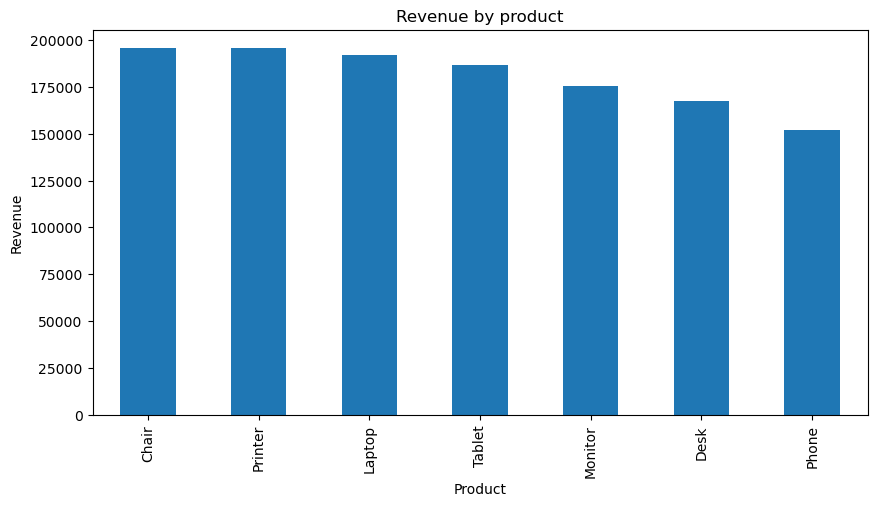

In [64]:
product_revenue.plot(kind ="bar", figsize=(10,5))
plt.title("Revenue by product")
plt.ylabel("Revenue")
plt.show()

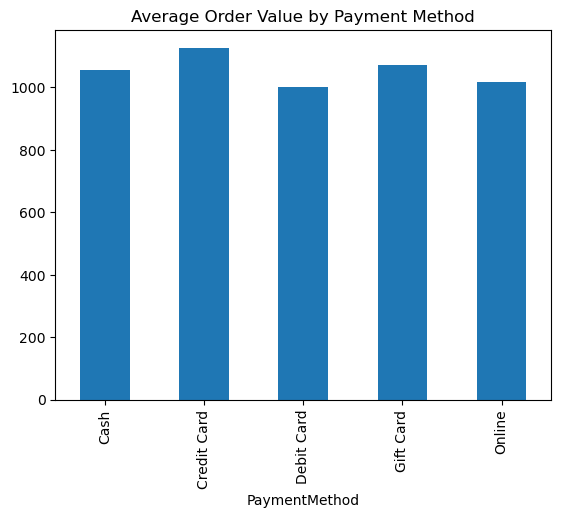

In [65]:
df.groupby('PaymentMethod')['TotalPrice'].mean().plot(kind='bar')
plt.title('Average Order Value by Payment Method')
plt.show()

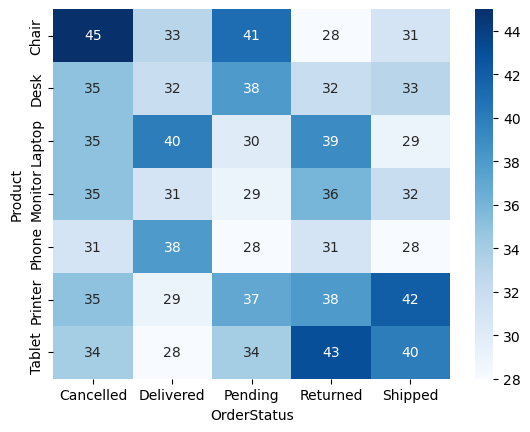

In [68]:
cross = pd.crosstab(df['Product'], df['OrderStatus'])
sns.heatmap(cross, annot=True, cmap='Blues')
plt.show()